# Discrete State Space
## Numerical Experiments

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Literal, Optional, Tuple, Union
import sys, time, logging, importlib
from pathlib import Path

import math
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

ROOT = Path('..').resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from mfc.algorithms import SimplexPerturbedMFREINFORCE
from mfc.environments import TwoStateMFC, TwoStateConfig
from mfc.environments import CybersecurityMFC, CybersecurityConfig, CybersecurityPolicy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

set_seed(0)
print(device)

cuda


## 1. Two-State Two-Action Toy Problem [Meunier2026][17]
References:
[17] Haotian Gu, Xin Guo, Xiaoli Wei, and Renyuan Xu. Dynamic programming principles for mean-field controls with learning. Operations Research, 71(4):1040–1054, 2023
[24] Diederik P Kingma. Adam: A method for stochastic optimization. arXiv preprint arXiv:1412.6980, 2014.


The action space is $\mathcal A=\{\mathrm{ST}, \mathrm{MV}\}$ and the state space is $\mathcal X = \{0, 1\}$. The transition kernel is defined as follows: for $x\in\mathcal X, a\in\mathcal A, P(x'\mid x,a)=\lambda_x\mathbf 1_{a=\mathrm{MV}}$ if $x'\neq x$ and $P(x'\mid x,a)=1-\lambda_x\mathbf 1_{a=\mathrm{MV}}$ if $x'=x$, where $\lambda_0,\lambda_1\in(0,1)$ are fixed parameters. The running reward function is defined as
\begin{align}
    r(x,a,\mu)=r(x\mu)=\mathbf 1_{x=1} - \mu(1)^2-\lambda W_1(\mu,B),
\end{align}
where $W_1$ is the 1-Wasserstein distance, $\lambda>0$ is a fixed scalar parameter and B is a Bernoulli distribution with parameter $p$ such that $1-\lambda_0\leq p\leq \lambda_1$. The terminal reward function is $g(x,\mu)=r(x,\mu)$. Although the original problem in [17] is an infinite-horizon discounted problem, we consider here a finite-horizon version with time horizon $T$. In this setting, there exists an optimal stationary policy given by
\begin{align}
    \pi^\star(a\mid 0,\mu) &= \left(1-\frac{1-p}{\lambda_0} \right)\mathbf 1_{\{a=\mathrm{ST} \}} + \frac{1-p}{\lambda_0}\mathbf 1_{\{a=\mathrm{MV}\}}, \\
    \pi^\star(a\mid 1,\mu) &= \left(1-\frac{p}{\lambda_1} \right)\mathbf 1_{\{a=\mathrm{ST}\}} +\frac{p}{\lambda_1}\mathbf 1_{\{a=\mathrm{MV}\}}.
\end{align}

We consider the same parameters as [Meunier2026]: $T=2,\lambda_0=0.5,\lambda_1=0.8,\lambda=10,p=0.6$. This policy guarantees that, no matter the initial distribution $\mu_0$, the distribution at all time steps $t\geq1$ is $\mu_t^\star=B$.

The training and evaluation are done as follows.
For each training episode we simulate the population starting from a random initial distribution $\mu=\mathcal P(\mathcal X)^\star$ by drawing $\mu(L)\sim\mathcal U([0.1,0.9])$. Every $10$ training episodes, we freeze the policy and sample a validation episode for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=(\mu_0(0),\mu_0(1))=(0.2,0.8)$. During training, we compute $N=200$ main perturbed trajectories for MF-REINFORCE and also use an empirical unperturbed population flow estimated from simulated particles, with $n=10$ auxiliary trajectories for the population-flow sensitivity estimator. For this
first example, the policy considered is a simple static policy that outputs a $|\mathcal X|\times|\mathcal A|$ matrix corresponding to the probability of each action given each state. We make this particular choice of policy to check whether MF-REINFORCE is capable of recovering the optimal static policy given above.
We use the Adam optimizer [24] and train for $5,000$ episodes using a learning rate of $10^{-3}$. The experiments are run for $\varepsilon$ ranging in the set $\{0.2,0.5,1.0,2.0\}$.


FINDINGS:
One can see that a larger value of $\varepsilon$ leads to faster increase in the value function at first, but yields worse final policies. In particular, we see that choosing ε too large can lead to catastophic failure. To evaluate how well the learned policies match the optimal static policy $\pi^\star$, we compute the average absolute errors in the resulting estimates of $\pi(\mathrm{ST}\mid 0)$ and $\pi(\mathrm{ST}\mid 1)$ over $5$ independent training runs for each value of $\varepsilon$ considered. The results are reported in Table 1. These results match adequately with the curves of Figure 1: the smaller $\varepsilon$, the better and closer to optimal the learned policy is.

In [2]:
# Configuration and parameters
config = TwoStateConfig(device=device, dtype=torch.float64)

N = 200     # Main perturbed trajectories for MF-REINFORCE
n = 10      # Auxiliary trajectories for population-flow sensitivity estimation
flow_particles = 200 # Particles for the empirical unperturbed population flow

lr = 1e-3   # Learning rate
n_train = 5 # Number of epochs
training_runs = 1 # Number of independent training runs for each epsilon value
validate_every = 10

epsilon_range = [0.05, 0.1, 0.2, 0.5] # Range of epsilon values to test

In [3]:
# Training
results_twostate = {}

for eps in epsilon_range:
    results_twostate[eps] = []
    eta_aux = eps
    eps_law = eps

    for run_idx in range(training_runs):
        env = TwoStateMFC(config)
        algorithm = SimplexPerturbedMFREINFORCE(env)

        theta = torch.nn.Parameter(torch.zeros(2, 2, dtype=config.dtype, device=config.device))
        optimizer = torch.optim.Adam([theta], lr=lr)
        fixed_mu0 = torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)

        history: Dict[str, List[float]] = {
            "episode": [],
            "validation_value": [],
            "train_return_mean": [],
            "grad_norm": [],
            "pi_st_0": [],
            "pi_st_1": [],
            "err_pi_st_0": [],
            "err_pi_st_1": [],
        }
        
        pi_star = env.optimal_policy()

        for episode in tqdm(range(n_train)):
            # Sample mu0 with mu0(1) ~ Uniform([low, high])
            mu1 = config.low + (config.high - config.low) * torch.rand((), dtype=config.dtype, device=config.device)
            mu0 = torch.stack([1.0 - mu1, mu1])

            with torch.no_grad():
                mu_hat_flow = algorithm.estimate_population_flow(theta.detach(), mu0, flow_particles)
                D_hat = algorithm.estimate_sensitivity(theta.detach(), mu_hat_flow, eta_aux, n)
                grad_hat, diag = algorithm.gradient_estimate(theta.detach(), mu_hat_flow, D_hat, eps_law, N, baseline="batch_mean")

            optimizer.zero_grad(set_to_none=True)
            theta.grad = -grad_hat.detach().clone()
            optimizer.step()

            if episode % validate_every == 0 or episode == n_train - 1:
                with torch.no_grad():
                    val = env.exact_value(theta.detach(), fixed_mu0)
                    pi = env.policy_probs(theta.detach())

                    history["episode"].append(float(episode))
                    history["validation_value"].append(float(val.item()))
                    history["train_return_mean"].append(float(diag["mean_return"].item()))
                    history["grad_norm"].append(float(diag["grad_norm"].item()))

                    history["pi_st_0"].append(float(pi[0, 0].item()))
                    history["pi_st_1"].append(float(pi[1, 0].item()))

                    history["err_pi_st_0"].append(float(torch.abs(pi[0, 0] - pi_star[0, 0]).item()))
                    history["err_pi_st_1"].append(float(torch.abs(pi[1, 0] - pi_star[1, 0]).item()))
    
        with torch.no_grad():
            final_pi = env.policy_probs(theta.detach())
            final_value = env.exact_value(theta.detach(), fixed_mu0)

        out = {
            "seed": run_idx,
            "eps_law": eps,
            "theta": theta.detach().clone(),
            "final_policy": final_pi.detach().clone(),
            "optimal_policy": pi_star.detach().clone(),
            "final_value": float(final_value.item()),
            "history": history,
            "config": config,
            "flow_particles": flow_particles,
        }
        results_twostate[eps].append(out)
        
    print(f"=== Training completed for eps={eps} over {training_runs} runs ===")
    print("Final validation values:", [run["final_value"] for run in results_twostate[eps]])
    print("Optimal policy")
    print(results_twostate[eps][0]["optimal_policy"])
    print()

100%|██████████| 5/5 [00:05<00:00,  1.05s/it]


=== Training completed for eps=0.05 over 1 runs ===
Final validation values: [-3.706039567315705]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')



100%|██████████| 5/5 [00:03<00:00,  1.32it/s]


=== Training completed for eps=0.1 over 1 runs ===
Final validation values: [-3.663971121075437]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')



100%|██████████| 5/5 [00:03<00:00,  1.30it/s]


=== Training completed for eps=0.2 over 1 runs ===
Final validation values: [-3.7056762675549813]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')



100%|██████████| 5/5 [00:03<00:00,  1.34it/s]

=== Training completed for eps=0.5 over 1 runs ===
Final validation values: [-3.652484366154159]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')



### Gradient sanity check

For a fixed policy parameter, we estimate $\widehat G_{\lambda,\eta,B,n}(\theta)$ with large batches using the empirical flow used by the algorithm, then compare its direction with an autograd oracle computed through the exact population flow. The primary diagnostic is cosine similarity against $\nabla_\theta J^\lambda(\theta)$; the unperturbed $\nabla_\theta J(\theta)$ is shown as a nearby reference.


In [4]:
# Gradient sanity check
sanity_eps = epsilon_range[0]
theta_check = results_twostate[sanity_eps][0]["theta"]
eps_law, eta_aux = sanity_eps, sanity_eps
n_aux: int = 1_000 # Consider bigger values for the check 
B: int = 2_000
flow_particles: int = 5_000
n_q_oracle: int = 20_000

env = TwoStateMFC(config)
algorithm = SimplexPerturbedMFREINFORCE(env)

mu0 = torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)
theta0 = theta_check.detach().clone().to(dtype=config.dtype, device=config.device)

with torch.no_grad():
    mu_hat_flow = algorithm.estimate_population_flow(theta0, mu0, flow_particles)
    exact_flow = env.exact_population_flow(theta0, mu0)
    D_hat = algorithm.estimate_sensitivity(theta0, mu_hat_flow, eta_aux, n_aux)
    grad_hat, diag = algorithm.gradient_estimate(theta0, mu_hat_flow, D_hat, eps_law, B, baseline="batch_mean")

theta_var = theta0.detach().clone().requires_grad_(True)

# Exact perturbed value mc
mu_flow = env.exact_population_flow(theta_var, mu0)
value = torch.zeros((), dtype=theta_var.dtype, device=theta_var.device)

for t in range(env.config.T + 1):
    q_t = algorithm.sample_q_batch(n_q_oracle)
    M_t = (1.0 - eps_law) * mu_flow[t].unsqueeze(0) + eps_law * q_t
    mu1 = M_t[:, 1]
    population_penalty = (-mu1.square() - env.config.lam * torch.abs(mu1 - env.config.target_p)).mean()
    state_reward = mu_flow[t, 1]
    value = value + state_reward + population_penalty

# Exact perturbed gradient mc
(grad,) = torch.autograd.grad(value, theta_var)
J_lam, grad_J_lam = value.detach(), grad.detach()

# Exact unperturbed gradient
value = env.exact_value(theta_var, mu0)
(grad,) = torch.autograd.grad(value, theta_var)
J, grad_J = value.detach(), grad.detach()

def cosine_similarity_flat(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x.flatten() @ y.flatten() / denom).item())

print("Cosine vs grad J_lambda:", cosine_similarity_flat(grad_hat, grad_J_lam))
print("Cosine vs grad J:", cosine_similarity_flat(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow).sum().item()))
print("Mean Return:", float(diag["mean_return"].item()))
print("Std. Return:", float(diag["std_return"].item()))

Cosine vs grad J_lambda: 0.9958499133971646
Cosine vs grad J: 0.9958442533850871
Norm G_hat: 9.550283463386862
Norm grad J_lambda: 4.538605940648404
Norm grad J: 4.753520684752198
J_lambda oracle MC: -3.5171229776706867
J oracle: -3.706039567315705
Empirical flow L1 error: 0.028448994503964598
Mean Return: -3.515258725265582
Std. Return: 1.0151145118250746


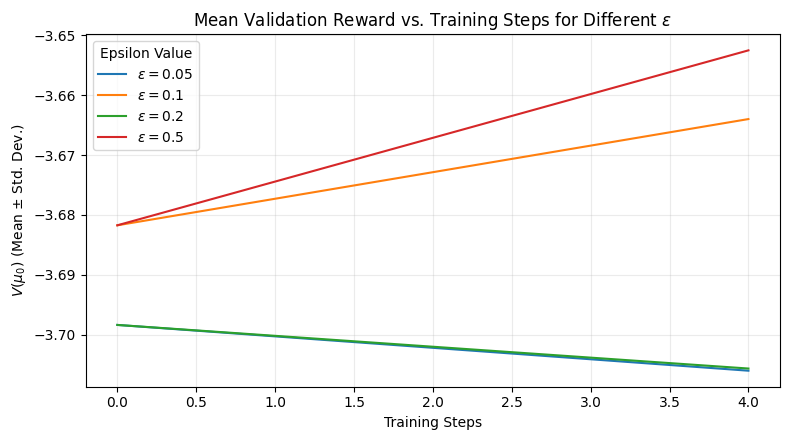

,avg_abs_err_pi(ST|0),std_abs_err_pi(ST|0),avg_abs_err_pi(ST|1),std_abs_err_pi(ST|1),avg_abs_err_policy
epsilon,,,,,
0.05,0.3004,0.0,0.2489,0.0,0.2746
0.10,0.2980,0.0,0.2514,0.0,0.2747
0.20,0.3009,0.0,0.2490,0.0,0.2750
0.50,0.2978,0.0,0.2523,0.0,0.2750


In [5]:
# Results
fig, ax = plt.subplots(figsize=(8, 4.5))
table_rows = []
std_ddof = 1 if training_runs > 1 else 0

for eps in epsilon_range:
    runs = results_twostate[eps]

    episodes = np.asarray(runs[0]["history"]["episode"], dtype=float)
    validation_rewards = np.asarray([run["history"]["validation_value"] for run in runs], dtype=float,)
    reward_mean = validation_rewards.mean(axis=0)
    reward_std = validation_rewards.std(axis=0, ddof=std_ddof)

    ax.plot(episodes, reward_mean, label=rf"$\varepsilon={eps}$")
    ax.fill_between(episodes, reward_mean - reward_std, reward_mean + reward_std, alpha=0.18)

    pi_star = runs[0]["optimal_policy"].detach().cpu().numpy()
    final_policies = np.asarray(
        [run["final_policy"].detach().cpu().numpy() for run in runs],
        dtype=float,
    )
    st_errors = np.abs(final_policies[:, :, 0] - pi_star[:, 0])

    table_rows.append(
        {
            "epsilon": eps,
            "avg_abs_err_pi(ST|0)": st_errors[:, 0].mean(),
            "std_abs_err_pi(ST|0)": st_errors[:, 0].std(ddof=std_ddof),
            "avg_abs_err_pi(ST|1)": st_errors[:, 1].mean(),
            "std_abs_err_pi(ST|1)": st_errors[:, 1].std(ddof=std_ddof),
            "avg_abs_err_policy": st_errors.mean(axis=1).mean(),
        }
    )

ax.set_title("Mean Validation Reward vs. Training Steps for Different $\\epsilon$")
ax.set_xlabel("Training Steps")
ax.set_ylabel("$V(\\mu_0)$ (Mean $\\pm$ Std. Dev.)")
ax.legend(title="Epsilon Value")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

table_1 = pd.DataFrame(table_rows).set_index("epsilon")
display(table_1.round(4))


## 2. Cybersecurity Example [Meunier2026][25][6]
References:
- [25] Vassili N Kolokoltsov and Alain Bensoussan. Mean-field-game model for botnet defense in cybersecurity. Applied Mathematics & Optimization, 74(3):669–692, 2016
- [6] Ren´e Carmona, Mathieu Lauri`ere, and Zongjun Tan. Model-free mean-field reinforcement learning: mean-field MDP and mean-field Q-learning. The Annals of Applied Probability, 33(6B):5334–5381, 2023

We consider a large population of computers.

Four states:
- DI: defended and infected
- DS: defended and susceptible
- UI: undefended and infected
- US: undefended and susceptible

Action space is $\mathcal A = \{0,1\}$, where $0$ means keeping the same level of protection $\mathrm D$ or $\mathrm U$, and $1$ means updating the level of protection (from $\mathrm D$ to $\mathrm U$ or vice versa).

When infected, the computer recovers at rate $q_\mathrm{rec}^D$ or $q_\mathrm{rec}^U$ depending on the level of protection. When susceptible, the computer might
be infected either directly by a hacker or by the other infected computers, at rates depending on the level of protection of the susceptible computer and the other infected computers.

Originally the problem was formulated in continuous time, and the infinitesimal generator matrix can be written, given the current distribution of the population $\mu$ and action chosen by the computer $a$, as
\begin{align}
    Q^{\mu, a} =
    \begin{pmatrix}
        \dots & q_{\mathrm{rec}}^D & \lambda a & 0 \\
        Q_{\mathrm{DS} \rightarrow \mathrm{DI}}^{\mu, a} & \dots & 0 & \lambda a \\
        \lambda a & 0 & \dots & q_\mathrm{rec}^U \\
        0 & \lambda a & Q_{\mathrm{US} \rightarrow \mathrm{UI}} & \dots  
    \end{pmatrix},
\end{align}
where
\begin{align}
    Q_{\mathrm{DS} \rightarrow \mathrm{DI}}^{\mu, a} &= v_H q_\mathrm{inf}^D + \beta_{\mathrm{DD}}\mu(\mathrm{DI}) + \beta_{\mathrm{UD}}\mu(UI), \\
    Q_{\mathrm{US} \rightarrow \mathrm{UI}}^{\mu, a} &= v_H q_\mathrm{inf}^U + \beta_\mathrm{UU}\mu(\mathrm{UI}) + \beta_\mathrm{DU}\mu(\mathrm{DI}),
\end{align}
and all instances of $\dots$ should be replaced by values to make each row sum to $0$.

Each computer incurs a cost whenever it is defended or infected. The individual cost per unit of time is given by $f(x) = k_D\mathbf 1_{x\in\{\mathrm{DI}, \mathrm{DS}\}} + k_I\mathbf 1_{x\in\{\mathrm{DI},\mathrm{UI} \}}.

The model is adapted to a discrete time setting by considering a time grid $0, \Delta t, 2\Delta t, \ldots, N_{\mathrm{epi}}\Delta t$. Between two points of the time grid, the transition matrix is given by $P_{\Delta t}^{\mu, a} = \exp(\Delta t Q^{\mu, a})$, and the running reward is $r_{\Delta t}(x, a, \mu) = r_{\Delta t}(x) = -\Delta t f(x)$.

For the numerical experiments, we use the same values for the parameters as in [Meunier2026]. The rewards are discounted by $\gamma =0.5$ and the terminal reward is taken to be the same as the running reward.

The training and evaluation are done as follows. As the transition probability is stationary and the terminal reward is the same as the step reward, the length of a training episode is taken to be $T_\mathrm{train}=3$ to mitigate the "curse of time" (cf. [Meunier2026] - Remark 3.2), and for each training episode we simulate the population starting from a random initial distribution $\mu\in \mathcal P(\mathcal X)^\star$. Every 10 training episodes, we freeze the policy and sample a validation episode of length $T_\mathrm{val}=50$, for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=(1/4, 1/4, 1/4, 1/4).
During training, the implementation below uses the same simplex-perturbed empirical-flow framework as in Problem 1. We compute $N=200$ main perturbed trajectories, estimate the unperturbed population flow from simulated particles, and use $n$ auxiliary trajectories for the population-flow sensitivity estimator. The policy is given by a 2-layer MLP, with 32 hidden units and tanh activations; it takes as input $t, \mu$ and outputs a $|\mathcal X|\times |\mathcal A|$ matrix corresponding to the probability of each action given each state.
We use the Adam optimizer with learning rate $10^{-3}$.
The experiments below use simplex perturbations $\varepsilon \in (0,1)$.

FINDINGS: We clearly see the effect of $\varepsilon$ on the variance of the overall training algorithm: the smaller the perturbation, the more erratic the gradient estimation becomes, which leads to slower convergence. Surprisingly, taking a smaller
value of epsilon does not lead to a better policy. To confirm that the policy obtained is not suboptimal, we compare the state distribution evolution under the learned policy to the results obtained in [6] with mean-field Q-learning. The resulting flow of distributions is shown in Figure 3. Clearly, we see that the qualitative behaviour of the population under the policy learned using
MF-REINFORCE eventually matches the one learned using mean-field Q-learning in [6].

In [6]:
# Configuration and parameters
config = CybersecurityConfig(device=device, dtype=torch.float64)

N = 200
n = 1
flow_particles = 200

lr = 1e-3
n_train = 5
training_runs = 1
validate_every = 10

epsilon_range = [0.2, 0.5, 0.8]

In [ ]:
# Training
results_cybersecurity = {}

for eps in epsilon_range:
    results_cybersecurity[eps] = []
    eps_law = eps
    eta_aux = eps
    for run_idx in range(training_runs):
        env = CybersecurityMFC(config)
        policy = CybersecurityPolicy(config)
        algorithm = SimplexPerturbedMFREINFORCE(env)
        optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
        fixed_mu0 = torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)

        history = {"episode": [], "validation_value": [], "train_return_mean": [], "grad_norm": []}

        for episode in tqdm(range(n_train)):
            alpha = torch.ones(config.n_states, dtype=config.dtype, device=config.device)
            mu0 = torch.distributions.Dirichlet(alpha).sample()
            mu_hat_flow = algorithm.estimate_population_flow(policy, mu0, flow_particles, horizon=config.T_train)
            D_hat = algorithm.estimate_sensitivity(policy, mu_hat_flow, eta_aux, n_aux)
            grad_hat, diag = algorithm.gradient_estimate(policy, mu_hat_flow, D_hat, eps_law, N, baseline="batch_mean")

            optimizer.zero_grad(set_to_none=True)
            # Assign flat gradient
            offset = 0
            sign = -1.0
            for p in policy.parameters():
                n = p.numel()
                p.grad = sign * grad_hat[offset:offset + n].reshape_as(p).detach().clone()
                offset += n
            optimizer.step()

            if episode % validate_every == 0 or episode == n_train - 1:
                with torch.no_grad(): val = env.exact_value(policy, fixed_mu0, config.T_val)
                history["episode"].append(float(episode))
                history["validation_value"].append(float(val.item()))
                history["train_return_mean"].append(float(diag["mean_return"].item()))
                history["grad_norm"].append(float(diag["grad_norm"].item()))

        out = {
            "seed": run_idx,
            "policy_state": {k: v.detach().cpu().clone() for k, v in policy.state_dict().items()},
            "final_value": float(env.exact_value(policy, fixed_mu0, config.T_val).detach().item()),
            "history": history,
            "eps_law": eps_law,
            "eta_aux": eta_aux,
            "config": config,
        }
        results_cybersecurity[eps].append(out)

    print(f"=== Cybersecurity training completed for eps={eps} over {training_runs} runs ===")
    print("Final validation values:", [run["final_value"] for run in results_cybersecurity[eps]])
    print()


100%|██████████| 5/5 [01:27<00:00, 17.53s/it]



=== Cybersecurity training completed for eps=0.2 over 1 runs ===
Final validation values: [-0.15948085924034194]


100%|██████████| 5/5 [01:39<00:00, 19.83s/it]



=== Cybersecurity training completed for eps=0.5 over 1 runs ===
Final validation values: [-0.15925280539074269]


 20%|██        | 1/5 [02:40<10:41, 160.49s/it]

In [ ]:
# Sanity Check
sanity_eps = epsilon_range[0]
cybersecurity_policy_sanity = CybersecurityPolicy(config)
eps_law, eta_aux = sanity_eps, sanity_eps
B: int = 512
n_aux: int = 64
flow_particles: int = 1_000
n_q_oracle: int = 512


env = CybersecurityMFC(config)
algorithm = SimplexPerturbedMFREINFORCE(env)
mu0 = torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)
mu_hat_flow = algorithm.estimate_population_flow(policy, mu0, flow_particles, horizon=config.T_train)
exact_flow = env.exact_population_flow(policy, mu0, config.T_train).detach()
D_hat = algorithm.estimate_sensitivity(policy, mu_hat_flow, eta_aux, n_aux)
grad_hat, diag = algorithm.gradient_estimate(policy, mu_hat_flow, D_hat, eps_law, B, baseline="batch_mean")

# Compute the exact perturbed value with MC
algorithm = SimplexPerturbedMFREINFORCE(env)
exact_flow = env.exact_population_flow(policy, mu0, config.T_train)
q_paths = algorithm.sample_q_batch(n_q_oracle * (config.T_train + 1)).reshape(n_q_oracle, config.T_train + 1, env.n_states)
value = torch.zeros((), dtype=env.config.dtype, device=env.config.device)

for r in range(n_q_oracle):
    state_law = mu0
    for t in range(config.T_train):
        M_t = (1.0 - eps_law) * exact_flow[t] + eps_law * q_paths[r, t]
        value = value + (env.config.gamma ** t) * (state_law * env.reward_by_state).sum()
        state_law = state_law @ env.averaged_kernel(policy, t, M_t)
    M_T = (1.0 - eps_law) * exact_flow[config.T_train] + eps_law * q_paths[r, config.T_train]
    value = value + (env.config.gamma ** config.T_train) * (state_law * env.reward_by_state).sum()

value = value / n_q_oracle

# Compute the exact perturbed gradient with MC
grads = torch.autograd.grad(value, tuple(policy.parameters()))
J_lam, grad_J_lam = value.detach(), torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

# Compute the exact unperturbed gradient
value = env.exact_value(policy, mu0, config.T_train)
grads = torch.autograd.grad(value, tuple(policy.parameters()))
J, grad_J = value.detach(), torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

# Helper cosine function
def cyber_cosine(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x @ y / denom).item())

print("Cosine vs grad J_lambda:", cyber_cosine(grad_hat, grad_J_lam))
print("Cosine vs grad J:", cyber_cosine(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow).sum().item()))
print("Mean Return:", float(diag["mean_return"].item()))
print("Std. Return:", float(diag["std_return"].item()))

### Results


In [ ]:
# Results
fig, ax = plt.subplots(figsize=(8, 4.5))
cyber_std_ddof = 1 if training_runs > 1 else 0

for eps in epsilon_range:
    runs = results_cybersecurity[eps]
    episodes = np.asarray(runs[0]["history"]["episode"], dtype=float)
    validation_rewards = np.asarray([run["history"]["validation_value"] for run in runs], dtype=float)
    reward_mean = validation_rewards.mean(axis=0)
    reward_std = validation_rewards.std(axis=0, ddof=cyber_std_ddof)
    ax.plot(episodes, reward_mean, label=rf"$\varepsilon={eps}$")
    ax.fill_between(episodes, reward_mean - reward_std, reward_mean + reward_std, alpha=0.18)

ax.set_title("Mean Validation Reward vs. Training Steps for Different $\\epsilon$")
ax.set_xlabel("Training Steps")
ax.set_ylabel("$V(\\mu_0)$ (Mean $\\pm$ Std. Dev.)")
ax.legend(title="Epsilon Value")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

flow_eps = 0.5 if 0.5 in results_cybersecurity else epsilon_range[0]
policy = CybersecurityPolicy(config)
policy.load_state_dict(results_cybersecurity[flow_eps][0]["policy_state"])

with torch.no_grad():
        flow = env.exact_population_flow(
            policy, torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device), config.T_val
        ).cpu().numpy()

# Benchmark values from Carmona, Laurière, Tan 2021
mfq_final_benchmark = {
    "UI": 0.43,
    "US": 0.57,
}

fig, ax = plt.subplots(figsize=(8, 4.5))
for state_idx, state_name in enumerate(config.cyber_state_names):
    ax.plot(np.arange(config.T_val + 1), flow[:, state_idx], label=state_name)

ax.axhline(mfq_final_benchmark["UI"], linestyle=":", color="tab:green", label="UI benchmark")
ax.axhline(mfq_final_benchmark["US"], linestyle=":", color="tab:red", label="US benchmark")

ax.set_title(f"State Distribution Over Time Using Learned Policy ($\\epsilon$={flow_eps})")
ax.set_xlabel("Time")
ax.set_ylabel("State probability")
ax.set_ylim(0.0, 1.0)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 3. Distribution Planning Example [Meunier2026][6]

References:
- [6] René Carmona, Mathieu Laurière, and Zongjun Tan. Model-free mean-field reinforcement learning: mean-field MDP and mean-field Q-learning. The Annals of Applied Probability, 33(6B):5334–5381, 2023


Consider a problem similar to the distribution planning example of [6] (Section 6.2). The goal is to match a fixed target distribution $\mu_\mathrm{target}\in\mathcal P(\mathcal X)$, where $\mathcal X=\mathbb Z/10\mathbb Z$. The action space is $\mathcal A=\{-1,0,+1\}$, and the transition probability is deterministic $P(\cdot\mid x,a,\mu)=\delta_{x+a}$. At each step, we penalize the deviation of the population from the target distribution and penalize when an agent chooses to move. Specifically, the step reward is $r(x,a,\mu)=-\lambda|a| -\sum_{x\in\mathcal X}|\mu(x)-\mu_\mathrm{target}(x)|^2$, where $\lambda>0$, and the terminal reward is $g(x,\mu)=-\sum_{x\in\mathcal X}|\mu(x)-\mu_\mathrm{target}(x)|^2$.

For each training episode, we simulate the population starting from a random initial distribution $\mu\in\mathcal P(\mathcal X)^\star$. Every 10 training episodes, we freeze the policy and sample a validation episode, for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=\mathcal U(\mathcal X)$. 

The policy is given by a 2-layer MLP, with 256 hidden units and tanh activation.

FINDINGS: he experiments are run for ε ranging in the set {0.5, 0.75, 1.0, 2.0}. In this example, we see that taking a large value of ε, i.e., ε ∈ {1, 2}, leads to more stable training and faster convergence, as shown in Figure 4. However, the resulting trajectories still differ qualitatively between ε = 1.0 and ε = 2.0, as seen in Figure 5.

In [ ]:
# Parameters
T = 5 # Length of episodes
lam = 0.01
N = 500 # Trajectories for MF-REINFORCE
n = 10 # Trajectories for the gradient of logits estimation

# MLP
n_layers = 2
hidden_units = 256
# activation: tanh

# optimizer: Adam
lr = 1e-4

epsilon_range = [0.05, 0.1, 0.2, 0.5]

training_runs = 5